# ResNet1D on raw EMG waveforms: training

Trains Wang et al. 2017's ResNet (`resnet1d.py`) on per-trial z-scored raw EMG (`loadData.py`) for Subject 1.
Settings and their sources are in `../../PLAN.md` (Step 3). Run from inside `training_runs/subject_01/`.

**How to use:** run the Setup, Training functions and Graphing sections once. Then each of sections 1–4 trains one
model type and graphs it, and can be run on its own. Everything a run produces goes to `results/`:
`results.json` (rewritten after each section, so
sections from earlier sessions are kept; **Overall statistics** at the end summarizes everything saved so far),
`progress.log` (appended to; `tail -f results/progress.log` to follow it), and one trained model per run.

## Setup

In [10]:
import json, os, sys, time, warnings

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")  # resnet1d/, for loadData.py and resnet1d.py
from loadData import loadZscoredTrainTestSplit
from resnet1d import resnet1dNet

# PyTorch warns that padding = "same" with the even kernel of 8 makes an internal padded copy; results are unaffected.
warnings.filterwarnings("ignore", message = "Using padding='same' with even kernel lengths")

In [11]:
numberSeeds = 5
numberEpochs = 300
batchSize = 32
device = torch.device("cuda:0")

print(torch.cuda.get_device_name(0), torch.__version__)

NVIDIA GeForce RTX 3090 2.14.0+cu130


In [12]:
def report(line):
    print(line)
    with open("results/progress.log", "a") as logFile:
        logFile.write(line + "\n")


# Results saved by earlier sessions are loaded, so any section can be (re)run on its own without losing the others.
results = json.load(open("results/results.json")) if os.path.exists("results/results.json") else {}
print("configs already in results.json:", list(results) or "none")

configs already in results.json: none


## Training functions

- `loadTrialsOntoGpu`: loads one recording with `loadData.py` (per-trial z-scoring, fixed 6/4 split) and moves it to the GPU.
- `evaluate`: test loss and accuracy, in eval mode, without gradients.
- `trainOneRun`: trains one fresh model for `numberEpochs` and returns its per-epoch history, plus a copy of the weights
  from the epoch with the highest test accuracy.
- `trainAllSeeds`: runs `trainOneRun` for every seed, reads the three test accuracies off each history, saves each run's
  model to `results/<config>_seed<N>_bestTestAccuracy.pt`, and saves everything else to `results/results.json`.

In [13]:
def loadTrialsOntoGpu(taskFolder, articulationManner):
    """taskFolder is "Phoneme" or "Words"; articulationManner is "Voiced" or "Unvoiced"."""
    trainTrials, trainLabels, testTrials, testLabels = loadZscoredTrainTestSplit(taskFolder, articulationManner)
    print(f"{taskFolder} {articulationManner}: train {trainTrials.shape}, test {testTrials.shape}")
    return [torch.from_numpy(array).to(device) for array in (trainTrials, trainLabels, testTrials, testLabels)]

In [14]:
def evaluate(model, trials, labels, lossFunction):
    """Mean loss and accuracy in eval mode (BatchNorm uses its running statistics, so trials don't affect each other)."""
    model.eval()
    lossSum, correctCount = 0.0, 0

    with torch.no_grad():
        for start in range(0, len(labels), batchSize):
            scores = model(trials[start:start + batchSize])
            batchLabels = labels[start:start + batchSize]

            lossSum += lossFunction(scores, batchLabels).item() * len(batchLabels)
            correctCount += (scores.argmax(dim = 1) == batchLabels).sum().item()

    return lossSum / len(labels), correctCount / len(labels)

In [15]:
def trainOneRun(trainTrials, trainLabels, testTrials, testLabels, seed):
    torch.manual_seed(seed)
    model = resnet1dNet(numberClasses = int(trainLabels.max()) + 1).to(device)
    lossFunction = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, betas = (0.9, 0.999), eps = 1e-8)
    # From Wang et al.'s code: halve the learning rate when training loss hasn't improved for 50 epochs, down to 1e-4.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience = 50, min_lr = 1e-4)

    history = {"trainLoss": [], "trainAccuracy": [], "testLoss": [], "testAccuracy": [], "learningRate": []}
    # Weights from the epoch with the highest test accuracy (first one on ties, like np.argmax), copied to the CPU.
    bestTestAccuracy, bestTestAccuracyWeights = -1, None

    report(" epoch  train loss  train acc  test loss  test acc       lr  s/epoch")
    startTime = time.time()
    for epoch in range(numberEpochs):
        model.train() # Set to train mode
        shuffledOrder = torch.randperm(len(trainLabels), device = device)
        lossSum, correctCount = 0.0, 0

        for start in range(0, len(shuffledOrder), batchSize):
            batchIndices = shuffledOrder[start:start + batchSize]
            scores = model(trainTrials[batchIndices]) # Gets inference scores in the suffled order
            loss = lossFunction(scores, trainLabels[batchIndices])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lossSum += loss.item() * len(batchIndices)
            correctCount += (scores.argmax(dim = 1) == trainLabels[batchIndices]).sum().item()

        # Training loss = average over this epoch's batches in train mode, like the Keras "loss" Wang's rule selects on.
        epochMetrics = {"trainLoss": lossSum / len(trainLabels),
                        "trainAccuracy": correctCount / len(trainLabels),
                        "learningRate": optimizer.param_groups[0]["lr"]}
        scheduler.step(epochMetrics["trainLoss"])
        epochMetrics["testLoss"], epochMetrics["testAccuracy"] = evaluate(model, testTrials, testLabels, lossFunction)

        for key, value in epochMetrics.items():
            history[key].append(value)

        if epochMetrics["testAccuracy"] > bestTestAccuracy:
            bestTestAccuracy = epochMetrics["testAccuracy"]
            bestTestAccuracyWeights = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

        # Print out status every 10 epochs
        if (epoch + 1) % 10 == 0:
            m = epochMetrics
            report(f"{epoch + 1:>6}  {m['trainLoss']:>10.4f}  {m['trainAccuracy']:>9.3f}  {m['testLoss']:>9.4f}  {m['testAccuracy']:>8.3f}"
                   f"  {m['learningRate']:>7.1e}  {(time.time() - startTime) / (epoch + 1):>7.2f}")

    return history, bestTestAccuracyWeights

In [16]:
# The three ways of turning a run's per-epoch test accuracies into one number (see PLAN.md, Step 3).
accuracyRuleLabels = {"testAccuracyAtLowestTrainLoss": "at lowest train loss (ours)",
                      "bestTestAccuracy": "best across epochs (ours)",
                      "finalTestAccuracy": "final epoch"}


def trainAllSeeds(configName, trainTrials, trainLabels, testTrials, testLabels):
    runs = []
    for seed in range(numberSeeds):
        report(f"=== {configName}, seed {seed}")

        history, bestTestAccuracyWeights = trainOneRun(trainTrials, trainLabels, testTrials, testLabels, seed)

        modelPath = f"results/{configName}_seed{seed}_bestTestAccuracy.pt"
        torch.save(bestTestAccuracyWeights, modelPath)

        lowestTrainLossEpoch = int(np.argmin(history["trainLoss"]))
        bestTestEpoch = int(np.argmax(history["testAccuracy"]))
        run = {"seed": seed,
               "testAccuracyAtLowestTrainLoss": history["testAccuracy"][lowestTrainLossEpoch],
               "lowestTrainLossEpoch": lowestTrainLossEpoch + 1,
               "bestTestAccuracy": history["testAccuracy"][bestTestEpoch],
               "bestTestAccuracyEpoch": bestTestEpoch + 1,
               "finalTestAccuracy": history["testAccuracy"][-1],
               "modelPath": modelPath,
               "history": history}

        report(f"test accuracy, {configName} seed {seed}:")
        report(f"  {accuracyRuleLabels['testAccuracyAtLowestTrainLoss']:<28} {run['testAccuracyAtLowestTrainLoss']:.3f}  (epoch {run['lowestTrainLossEpoch']})")
        report(f"  {accuracyRuleLabels['bestTestAccuracy']:<28} {run['bestTestAccuracy']:.3f}  (epoch {run['bestTestAccuracyEpoch']})")
        report(f"  {accuracyRuleLabels['finalTestAccuracy']:<28} {run['finalTestAccuracy']:.3f}")
        report(f"  saved model from epoch {run['bestTestAccuracyEpoch']} to {modelPath}")
        runs.append(run)

    results[configName] = {"numberClasses": int(trainLabels.max()) + 1,
                           "numberTestTrials": len(testLabels),
                           "numberEpochs": numberEpochs,
                           "batchSize": batchSize,
                           "numberSeeds": numberSeeds,
                           "runs": runs}
    with open("results/results.json", "w") as resultsFile:
        json.dump(results, resultsFile)

## Graphing function

`plotTrainingCurves` draws one config's train/test accuracy and training loss over epochs
(mean over seeds, shaded min–max when there is more than one seed). It reads from `results`, so it also works for configs saved to `results/results.json` in an earlier session.

In [17]:
def plotTrainingCurves(configName):
    config = results[configName]
    epochNumbers = np.arange(1, config["numberEpochs"] + 1)
    fig, (accuracyAxis, lossAxis) = plt.subplots(1, 2, figsize = (12, 3.5))

    # Left: train and test accuracy
    for key, label in [("trainAccuracy", "train"), ("testAccuracy", "test")]:
        valuesBySeed = np.array([run["history"][key] for run in config["runs"]])
        accuracyAxis.plot(epochNumbers, valuesBySeed.mean(0), label = label)
        accuracyAxis.fill_between(epochNumbers, valuesBySeed.min(0), valuesBySeed.max(0), alpha = 0.2)
    accuracyAxis.axhline(1 / config["numberClasses"], color = "gray", ls = ":", lw = 1, label = "chance")
    accuracyAxis.set(title = configName + ": accuracy", xlabel = "epoch", ylabel = "accuracy")
    accuracyAxis.legend(fontsize = 8)

    # Right: training loss, log scale
    trainLossBySeed = np.array([run["history"]["trainLoss"] for run in config["runs"]])
    lossAxis.semilogy(epochNumbers, trainLossBySeed.mean(0))
    lossAxis.set(title = configName + ": training loss", xlabel = "epoch", ylabel = "train loss (log)")

    plt.tight_layout()
    plt.show()

## 1. All phonemes, voiced

In [18]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Phoneme", "Voiced")
trainAllSeeds("allPhonemes_Voiced", trainTrials, trainLabels, testTrials, testLabels)

Phoneme Voiced: train (228, 22, 7500), test (152, 22, 7500)
=== allPhonemes_Voiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch
    10      2.8121      0.193     2.8090     0.145  1.0e-03     0.60
    20      2.2219      0.368     3.2874     0.125  1.0e-03     0.60
    30      1.7620      0.592     2.3595     0.270  1.0e-03     0.60
    40      1.4697      0.601     2.0893     0.342  1.0e-03     0.61
    50      1.2312      0.746     2.5560     0.257  1.0e-03     0.62
    60      1.0653      0.741     1.7204     0.454  1.0e-03     0.62
    70      0.9596      0.781     1.9404     0.421  1.0e-03     0.62
    80      0.7943      0.842     1.4936     0.500  1.0e-03     0.62
    90      0.7221      0.873     3.1035     0.224  1.0e-03     0.63
   100      0.6757      0.899     3.3189     0.217  1.0e-03     0.63
   110      0.5333      0.921     1.5281     0.546  1.0e-03     0.63
   120      0.5609      0.904     4.2828     0.132  1.0e-03     0.63
   130      

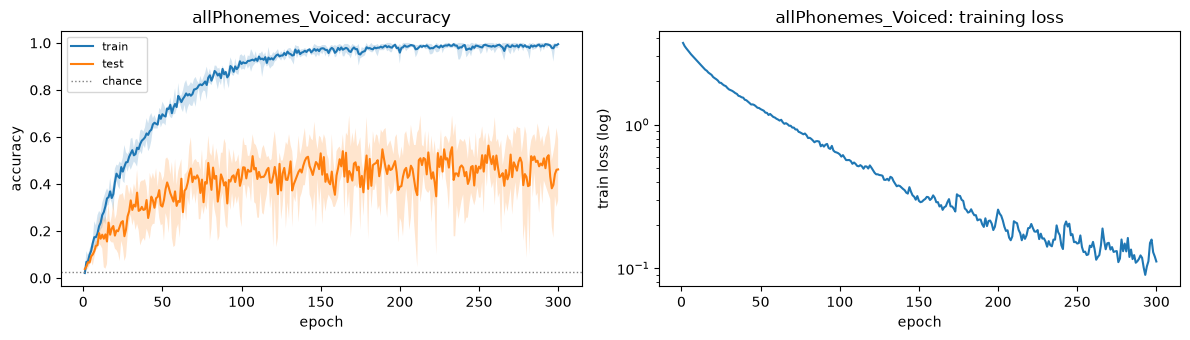

In [19]:
plotTrainingCurves("allPhonemes_Voiced")

## 2. All phonemes, unvoiced

In [20]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Phoneme", "Unvoiced")
trainAllSeeds("allPhonemes_Unvoiced", trainTrials, trainLabels, testTrials, testLabels)

Phoneme Unvoiced: train (228, 22, 7500), test (152, 22, 7500)
=== allPhonemes_Unvoiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch
    10      2.5616      0.298     2.7728     0.197  1.0e-03     0.59
    20      1.9691      0.417     2.4649     0.257  1.0e-03     0.59
    30      1.6061      0.544     2.0498     0.329  1.0e-03     0.59
    40      1.3211      0.711     2.1335     0.329  1.0e-03     0.59
    50      1.0767      0.746     2.7559     0.230  1.0e-03     0.59
    60      1.0124      0.746     1.9641     0.395  1.0e-03     0.59
    70      0.8657      0.825     1.9185     0.368  1.0e-03     0.59
    80      0.7597      0.816     1.5557     0.467  1.0e-03     0.59
    90      0.6950      0.855     1.9400     0.441  1.0e-03     0.59
   100      0.5998      0.899     1.9106     0.414  1.0e-03     0.59
   110      0.5327      0.912     2.5803     0.257  1.0e-03     0.59
   120      0.4879      0.934     1.5663     0.500  1.0e-03     0.59
   130  

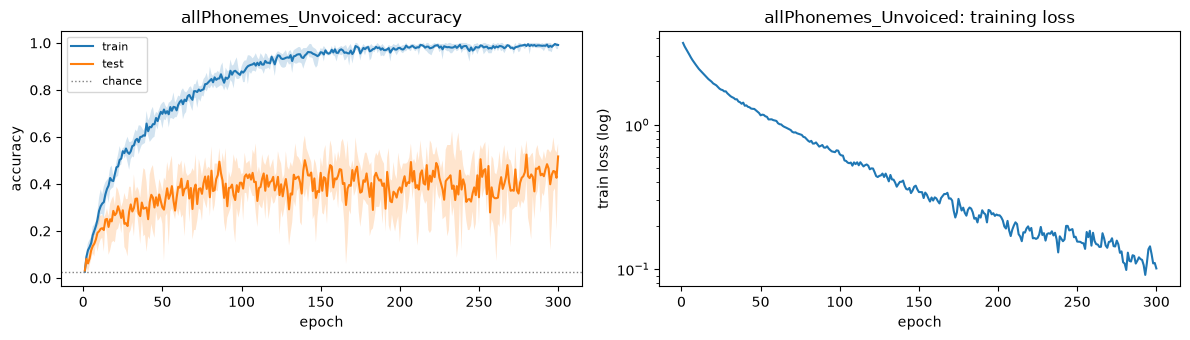

In [21]:
plotTrainingCurves("allPhonemes_Unvoiced")

## 3. All words, voiced

In [22]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Words", "Voiced")
trainAllSeeds("allWords_Voiced", trainTrials, trainLabels, testTrials, testLabels)

Words Voiced: train (216, 22, 7500), test (144, 22, 7500)
=== allWords_Voiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch
    10      2.6674      0.301     2.7571     0.250  1.0e-03     0.56
    20      1.9911      0.588     2.4734     0.278  1.0e-03     0.56
    30      1.4391      0.792     1.9857     0.403  1.0e-03     0.56
    40      1.0484      0.898     1.6307     0.569  1.0e-03     0.56
    50      0.7117      0.981     1.6773     0.507  1.0e-03     0.56
    60      0.5054      0.981     1.8462     0.389  1.0e-03     0.56
    70      0.3242      0.991     2.2821     0.292  1.0e-03     0.56
    80      0.2354      1.000     2.0454     0.396  1.0e-03     0.56
    90      0.1473      1.000     1.1128     0.701  1.0e-03     0.56
   100      0.1092      1.000     1.1002     0.667  1.0e-03     0.56
   110      0.0743      1.000     0.9862     0.750  1.0e-03     0.56
   120      0.1032      0.991     1.9923     0.451  1.0e-03     0.56
   130      0.046

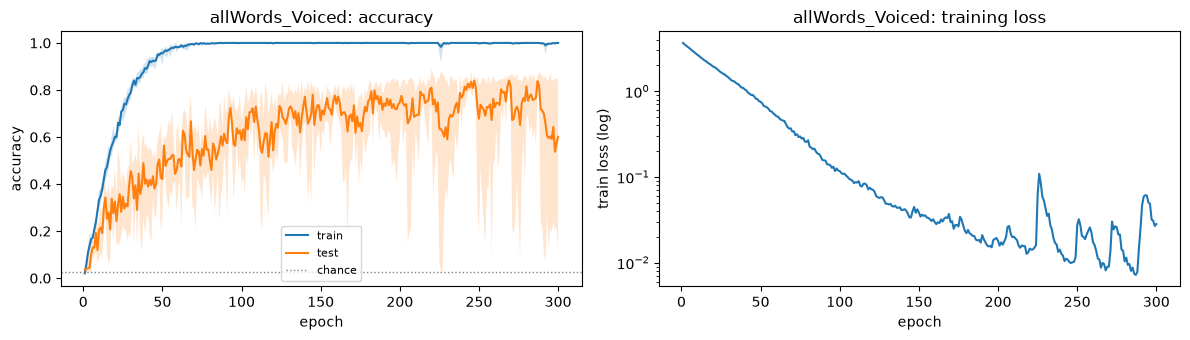

In [23]:
plotTrainingCurves("allWords_Voiced")

## 4. All words, unvoiced

In [24]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Words", "Unvoiced")
trainAllSeeds("allWords_Unvoiced", trainTrials, trainLabels, testTrials, testLabels)

Words Unvoiced: train (216, 22, 7500), test (144, 22, 7500)
=== allWords_Unvoiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch
    10      2.6038      0.361     2.7395     0.181  1.0e-03     0.56
    20      1.8846      0.579     2.4531     0.243  1.0e-03     0.56
    30      1.3844      0.741     2.1813     0.340  1.0e-03     0.56
    40      1.0880      0.829     2.4181     0.257  1.0e-03     0.56
    50      0.8077      0.921     2.5530     0.306  1.0e-03     0.56
    60      0.5634      0.968     2.0022     0.403  1.0e-03     0.56
    70      0.4181      0.977     1.9544     0.361  1.0e-03     0.56
    80      0.3046      1.000     2.0335     0.410  1.0e-03     0.56
    90      0.2059      1.000     2.1985     0.319  1.0e-03     0.56
   100      0.1602      1.000     4.5604     0.153  1.0e-03     0.56
   110      0.1238      1.000     1.7975     0.493  1.0e-03     0.56
   120      0.0844      1.000     1.4713     0.569  1.0e-03     0.56
   130      0

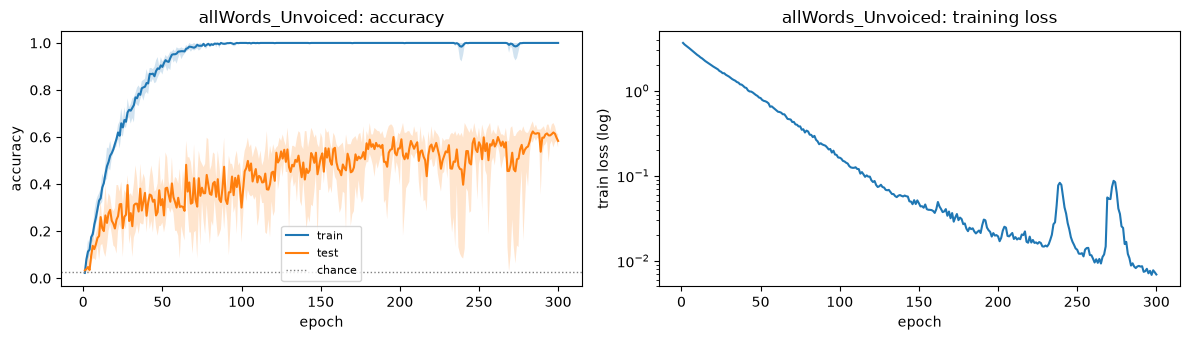

In [25]:
plotTrainingCurves("allWords_Unvoiced")

## Overall statistics

Our ResNet1D's test accuracy per config, at the lowest-training-loss epoch and at the best epoch (mean ± std over seeds; std is 0 with one seed), from everything in `results/results.json`, next to the paper's SPD-RNN result for the same subject and config (Gowda et al., Table 10 column A for phonemes, Table 11 for words; mean ± std over 10 seeds). The paper reports the best test accuracy across epochs, so compare it with the "best across epochs (ours)" column; the paper has no lowest-training-loss equivalent.

In [26]:
# Paper's SPD-RNN accuracy for Subject 1 (Gowda et al., Table 10 column A and Table 11): mean, std over 10 seeds.
paperSpdRnnAccuracies = {"allPhonemes_Voiced": (0.651, 0.03), "allPhonemes_Unvoiced": (0.574, 0.014),
                         "allWords_Voiced": (0.788, 0.029), "allWords_Unvoiced": (0.669, 0.055)}

print(f"{'config':<22} {'classes':>7} {'chance':>7} {'seeds':>5} {'epochs':>6}   "
      + f"{accuracyRuleLabels['testAccuracyAtLowestTrainLoss']:>27}   {accuracyRuleLabels['bestTestAccuracy']:>27}   {'SPD-RNN (paper)':>27}")

for configName, config in results.items():
    accuracyCells = []
    for ruleKey in ["testAccuracyAtLowestTrainLoss", "bestTestAccuracy"]:
        accuracies = np.array([run[ruleKey] for run in config["runs"]])
        accuracyCells.append(f"{accuracies.mean():.3f} ± {accuracies.std():.3f}")
    paperMean, paperStd = paperSpdRnnAccuracies[configName]
    accuracyCells.append(f"{paperMean:.3f} ± {paperStd:.3f}")

    print(f"{configName:<22} {config['numberClasses']:>7} {1 / config['numberClasses']:>7.3f} {config['numberSeeds']:>5} {config['numberEpochs']:>6}   "
          + "   ".join(f"{accuracyCell:>27}" for accuracyCell in accuracyCells))

config                 classes  chance seeds epochs   at lowest train loss (ours)     best across epochs (ours)               SPD-RNN (paper)
allPhonemes_Voiced          38   0.026     5    300                 0.564 ± 0.056                 0.667 ± 0.020                 0.651 ± 0.030
allPhonemes_Unvoiced        38   0.026     5    300                 0.457 ± 0.059                 0.601 ± 0.021                 0.574 ± 0.014
allWords_Voiced             36   0.028     5    300                 0.853 ± 0.010                 0.879 ± 0.006                 0.788 ± 0.029
allWords_Unvoiced           36   0.028     5    300                 0.614 ± 0.019                 0.657 ± 0.006                 0.669 ± 0.055


### Matched epoch budget: first 150 epochs

The paper's SPD-RNN notebooks train for 150 epochs, so its best-across-epochs number had 150 chances; ours had `numberEpochs`.
This recomputes our accuracies (at the lowest training loss, and the best) using only epochs 1–150 of each run's saved history (no retraining), for a same-rule, same-budget comparison.

In [ ]:
paperEpochs = 150   # numberEpochs in allPhonemesRnn.ipynb / wordsRnn.ipynb

print(f"{'config':<22} {'seeds':>5}   {'lowest train loss, 1-150':>27}   {'best, epochs 1-150 (ours)':>27}   {'SPD-RNN (paper)':>27}")

for configName, config in results.items():
    testAccuraciesBySeed = [run["history"]["testAccuracy"][:paperEpochs] for run in config["runs"]]
    trainLossesBySeed = [run["history"]["trainLoss"][:paperEpochs] for run in config["runs"]]
    lowestTrainLossAccuracies = np.array([testAccuracies[int(np.argmin(trainLosses))]
                                          for testAccuracies, trainLosses in zip(testAccuraciesBySeed, trainLossesBySeed)])
    accuracies = np.array([max(testAccuracies) for testAccuracies in testAccuraciesBySeed])
    paperMean, paperStd = paperSpdRnnAccuracies[configName]

    print(f"{configName:<22} {config['numberSeeds']:>5}   {f'{lowestTrainLossAccuracies.mean():.3f} ± {lowestTrainLossAccuracies.std():.3f}':>27}"
          f"   {f'{accuracies.mean():.3f} ± {accuracies.std():.3f}':>27}   {f'{paperMean:.3f} ± {paperStd:.3f}':>27}")

config                 seeds      lowest train loss, 1-150     best, epochs 1-150 (ours)               SPD-RNN (paper)
allPhonemes_Voiced         5                 0.501 ± 0.088                 0.617 ± 0.031                 0.651 ± 0.030
allPhonemes_Unvoiced       5                 0.462 ± 0.056                 0.572 ± 0.018                 0.574 ± 0.014
allWords_Voiced            5                 0.740 ± 0.046                 0.828 ± 0.019                 0.788 ± 0.029
allWords_Unvoiced          5                 0.517 ± 0.068                 0.628 ± 0.010                 0.669 ± 0.055
